In [3]:
from langchain_openai import ChatOpenAI # 这个是用来创建llm client的函数
from langchain_community.tools.tavily_search import TavilySearchResults # 联网搜索工具
from langgraph.graph import StateGraph, MessagesState, START,END # 这个使用来创建graph所需的函数、类、对象
from langgraph.prebuilt import ToolNode # 创建工具节点的类，这个可能outofdate了
import textwrap


[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
C:\Users\Ryan\AppData\Local\Temp\ipykernel_18604\2310432489.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults # 联网搜索工具


In [4]:
# 创建工具
search = TavilySearchResults(max_results=2,tavily_api_key = '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' )

C:\Users\Ryan\AppData\Local\Temp\ipykernel_18604\3855804427.py:2: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  search = TavilySearchResults(max_results=2,tavily_api_key = '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' )


In [5]:
# 创建llm client并绑定工具
llm = ChatOpenAI(
    api_key="d1de7475090740ebb6c887167a6a8b98.2WUSfYbmgQwYLKF4",
    base_url="https://open.bigmodel.cn/api/paas/v4/",
    model="glm-5.2",
)
tools = [search]
llm_with_tools = llm.bind_tools(tools)


In [6]:
# 创建agent node
def agent(state: MessagesState):
#     system_message = """你是一个 ReAct (Reasoning + Acting) Agent。
# 处理用户问题时，请遵循以下步骤：
# 1. Thought(思考)：分析问题需要什么信息
# 2. Action(行动)：决定调用哪个工具
# 3. Observation(观察)：分析工具返回的结果
# 4. Answer(回答)：基于观察给出最终答案

# 始终展示你的推理过程。"""
    system_message = """你是一个 ReAct (Reasoning + Acting) Agent。
处理用户问题时，请遵循以下步骤进行推理：
1. Thought（思考）：分析问题需要什么信息
2. Action（行动）：决定调用哪个工具
3. Observation（观察）：分析工具返回的结果
4. Answer（回答）：基于观察给出最终答案

始终展示你的四步推理过程。"""
    messages = [{"role": "system", "content": system_message}] + state["messages"]

    return {"messages": [llm_with_tools.invoke(messages)]}

In [7]:
# 创建条件表,它的返回必须时注册过的节点id，或者END
def should_continue(state:MessagesState):
    last_message = state['messages'][-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
    return END

In [8]:
# 构建图
graph = StateGraph(MessagesState)
graph.add_node("agent" ,agent)
graph.add_node("tools", ToolNode(tools))# tools已经在llm实例上绑定过了，不过那只是告诉模型有这些tool，这里的tool节点是真正运行tool的节点

graph.add_edge(START, "agent")
graph.add_conditional_edges("agent", should_continue, ["tools",END])
graph.add_edge("tools", "agent")

In [9]:
# 根据图模型创建运行时
app = graph.compile()

In [10]:
# 测试我们的agent
response = app.invoke(
    {
        "messages": [
            ("user", "2024年诺贝尔物理学奖的获得者是谁，他们的主要贡献是什么？")
        ]
    },
    # config={"recursion_limit": 5},
)

In [13]:
# print(response["messages"][-1].model_dump_json(indent = 2))
for msg in response["messages"]:
    print(f"""{type(msg).__name__}
{msg.model_dump_json(indent = 2)}
------------------
""")

HumanMessage
{
  "content": "2024年诺贝尔物理学奖的获得者是谁，他们的主要贡献是什么？",
  "additional_kwargs": {},
  "response_metadata": {},
  "type": "human",
  "name": null,
  "id": "80b5b99f-e8ef-4d6f-ada9-9d535a4460fe"
}
------------------

AIMessage
{
  "content": "",
  "additional_kwargs": {
    "refusal": null
  },
  "response_metadata": {
    "token_usage": {
      "completion_tokens": 52,
      "prompt_tokens": 286,
      "total_tokens": 338,
      "completion_tokens_details": {
        "accepted_prediction_tokens": null,
        "audio_tokens": null,
        "reasoning_tokens": 27,
        "rejected_prediction_tokens": null
      },
      "prompt_tokens_details": {
        "audio_tokens": null,
        "cache_write_tokens": null,
        "cached_tokens": 0
      }
    },
    "model_provider": "openai",
    "model_name": "glm-5.2",
    "system_fingerprint": null,
    "id": "202608191432304178293c9ff540c9",
    "finish_reason": "tool_calls",
    "logprobs": null
  },
  "type": "ai",
  "name": null,
  "

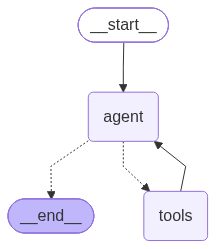

In [12]:
from IPython.display import display, Image

display(Image(app.get_graph().draw_mermaid_png()))